In [65]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
print(tf.__version__)
print(np.__version__)

2.19.0
2.0.2


In [66]:
fashion_mnist =  tf.keras.datasets.fashion_mnist
(train_images, train_labels), (test_images,test_labels) = fashion_mnist.load_data()

In [67]:
train_images = train_images / 255.0
test_images = test_images / 255.0


In [68]:
# The fashion_mnist.load_data() function only downloads the raw images and their numerical IDs (0–9). The text labels (like "Sneaker" or "Dress") are not stored inside the NumPy arrays or the compressed files.
class_names = [
    'T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
    'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot'
]

In [69]:
model = tf.keras.Sequential([
    tf.keras.Input(shape=(28, 28)), # Define input shape explicitly
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(10, activation=tf.nn.softmax)
])
model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_6 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

In [70]:
#  Total params: 101,770  = 784 * 128 + 128 + 128 * 10 + 10
# z = (w1 * x1 + w2 * x2) + b
# Bias : There is only one bias per neuron because the bias is just an "adjustment" to the final sum before it goes to the activation function (ReLU).


In [71]:
model.compile(optimizer=tf.keras.optimizers.Adam(),
              loss='sparse_categorical_crossentropy',
              metrics= ['accuracy'])

In [72]:
# cross-entropy-loss
# backpropagation
# adam
hist = model.fit(train_images, train_labels, batch_size=64,
                 epochs=5,
                 validation_data=(test_images, test_labels))

Epoch 1/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.7761 - loss: 0.6607 - val_accuracy: 0.8419 - val_loss: 0.4401
Epoch 2/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.8583 - loss: 0.3892 - val_accuracy: 0.8594 - val_loss: 0.3973
Epoch 3/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.8757 - loss: 0.3447 - val_accuracy: 0.8653 - val_loss: 0.3800
Epoch 4/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.8842 - loss: 0.3157 - val_accuracy: 0.8679 - val_loss: 0.3645
Epoch 5/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.8903 - loss: 0.3024 - val_accuracy: 0.8690 - val_loss: 0.3549


In [73]:
test_loss, test_acc = model.evaluate(test_images, test_labels)
print('Test accuracy:', test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8699 - loss: 0.3555
Test accuracy: 0.8690000176429749


In [74]:
predictions = model.predict(test_images)
results = np.argmax(predictions, axis=1)
print("multi image imput shape => ", test_images.shape)
print("predict output => " ,predictions.shape)
print("result shape => ", results.shape)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
multi image imput shape =>  (10000, 28, 28)
predict output =>  (10000, 10)
result shape =>  (10000,)


In [75]:
print(results[0])

9


In [76]:
def plot_image(axi,i,predictions,labels, imgs):
  prediction, labels,  imgs = predictions[i], labels[i], imgs[i]
  results = np.argmax(prediction)
  axi.grid(False)
  axi.set_xticks([])
  axi.set_yticks([])
  axi.imshow(imgs, cmap=plt.cm.binary)
  color = "blue" if results == labels else "red"
  axi.set_xlabel(
      xlabel="{} {:2.0f}% (GT: {})".format(class_names[results],
                                           100*np.max(prediction),
                                           class_names[labels])
  )
  axi.xaxis.label.set_color(color)


In [77]:
def plot_prediction(axi, i, predictions, labels):
  prediction, labels = predictions[i], labels[i]
  results = np.argmax(prediction)
  axi.grid(True)
  axi.set_xticks([])
  axi.set_yticks([0, 0.5, 1])
  bar_plt = axi.bar(range(10), prediction, color="#777777")
  bar_plt[results].set_color('red')
  bar_plt[labels].set_color('blue')
  axi.set_ylim([0, 1])

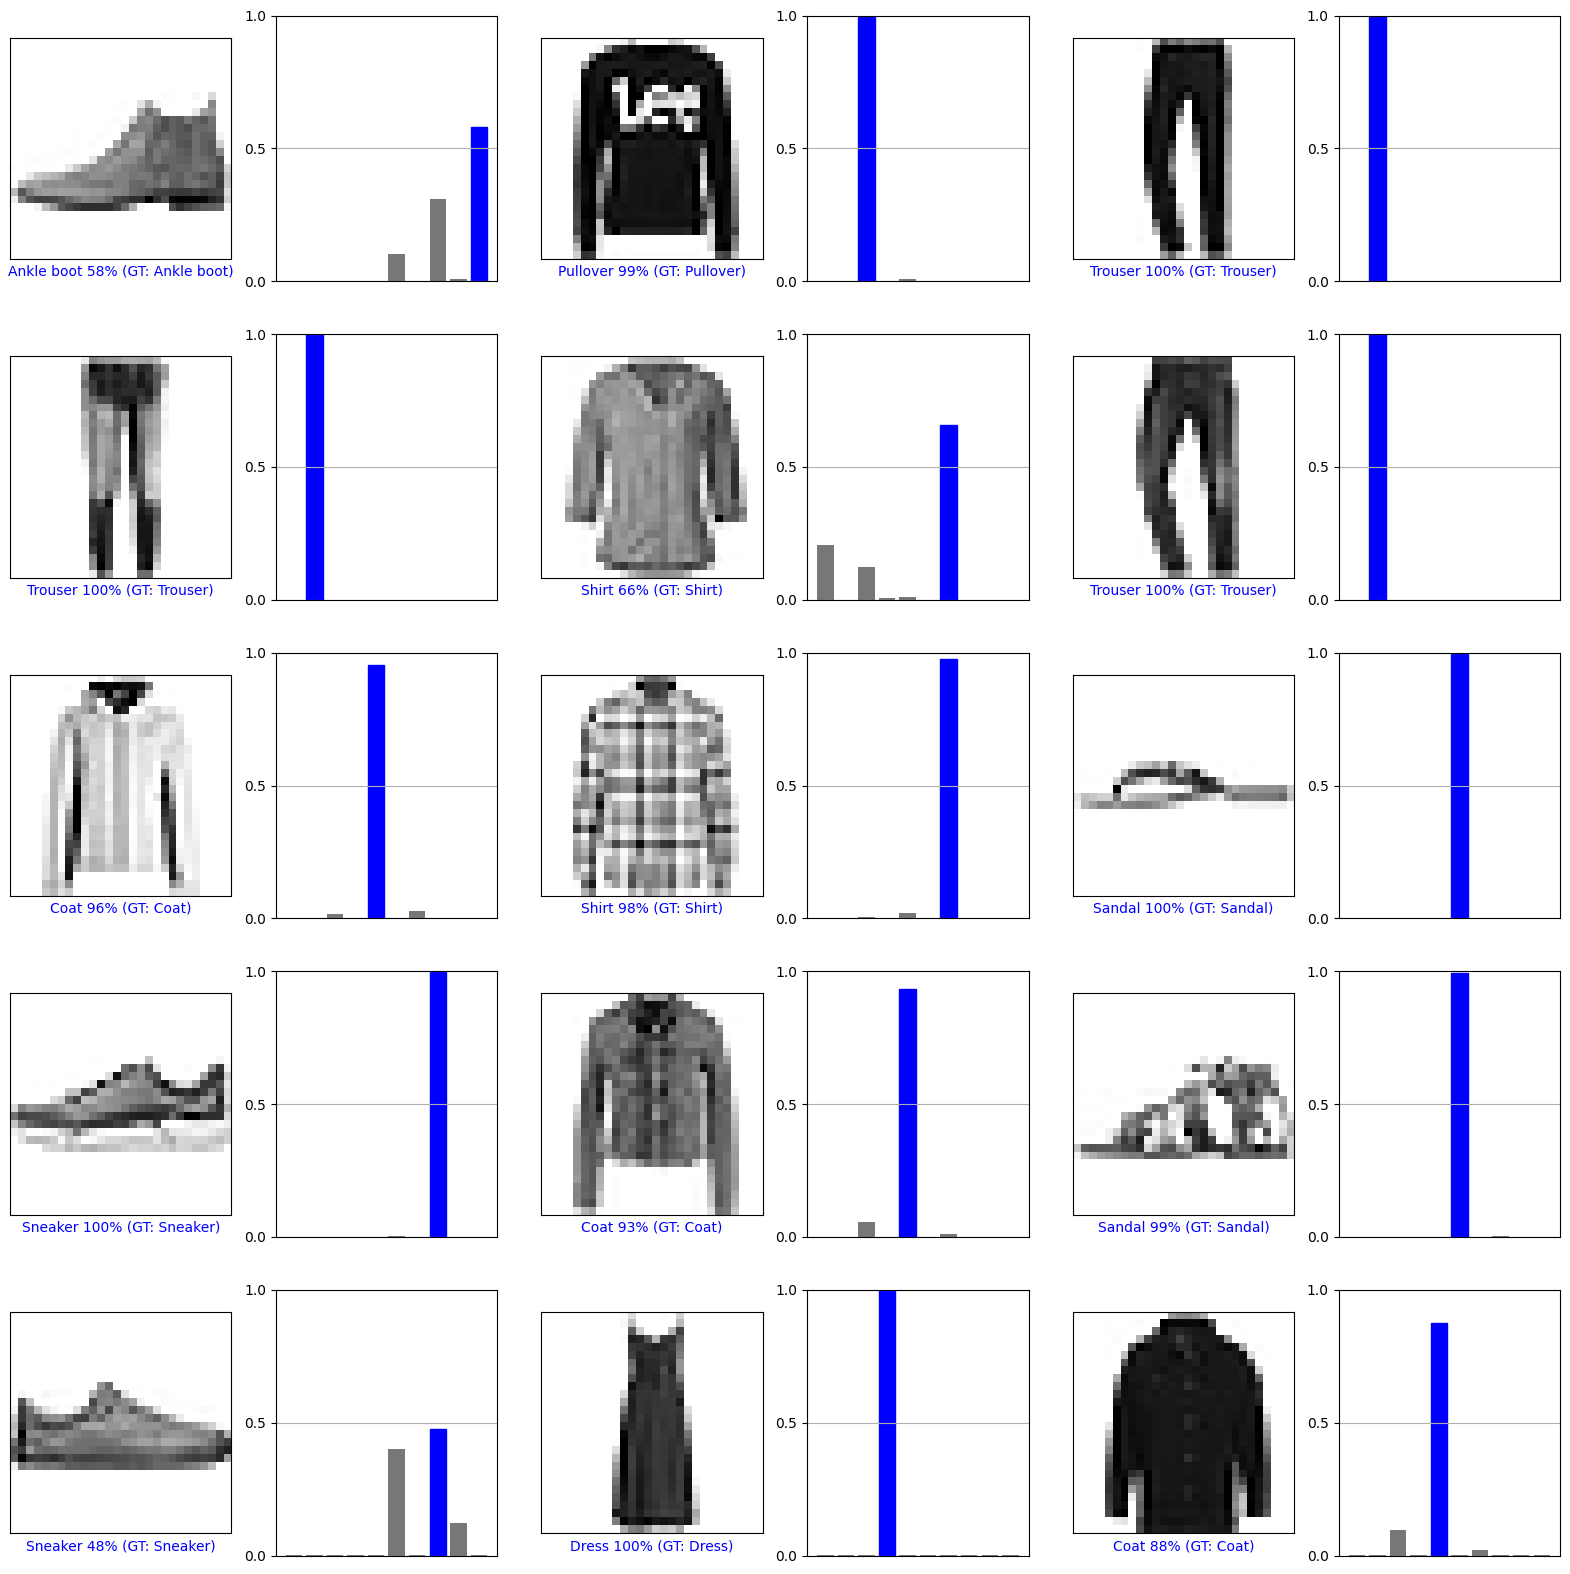

In [78]:
imgs_per_row = 3
num_row = 5
fig, ax = plt.subplots(num_row, ncols=2*imgs_per_row, figsize=(20, 20))
for i in range(num_row):
  for j in range(imgs_per_row):
    img_index = i*imgs_per_row + j
    plot_image(ax[i, j*2], img_index,
               predictions, test_labels, test_images)
    plot_prediction(ax[i, j*2+1], img_index,
                    predictions, test_labels)